# Wine dataset GMM Clustering

## 개요
- Wine 데이터셋에 Gaussian Mixture Model 적용
- 확률 기반 Soft Clustering 수행
- 가우시안 분포로 각 군집 모델링

## 주요 단계
1. 데이터 로드 및 정규화
2. PCA 차원 축소
3. GMM 모델 학습 및 예측
4. 시각화

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

## 1. 데이터 로드 및 전처리

In [15]:
# dataset load
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)

# 데이터 정규화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"데이터 크기: {X.shape}")

데이터 크기: (178, 13)


## 2. 차원 축소(PCA)

In [16]:
# PCA 적용
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"설명된 분산 비율: {pca.explained_variance_ratio_}")
print(f"총 설명된 분산: {sum(pca.explained_variance_ratio_):.2%}")

설명된 분산 비율: [0.36198848 0.1920749 ]
총 설명된 분산: 55.41%


## 3. GMM 모델 생성 및 학습

In [17]:
# GMM 모델 생성
# n_components: 군집 개수
gmm = GaussianMixture(n_components=3, random_state=42)

# GMM 학습
gmm.fit(X_pca)

# 예측
labels = gmm.predict(X_pca)

print(f"발견된 군집 개수: {len(np.unique(labels))}")
print(f"\n군집 중심점 (평균):\n{gmm.means_}")

발견된 군집 개수: 3

군집 중심점 (평균):
[[-0.13663617 -1.71241678]
 [-2.7667918   1.23902362]
 [ 2.26611726  0.90317491]]


In [18]:
# 군집별 샘플 개수
for k in range(3):
    count = np.sum(labels == k)
    print(f"클러스터 {k}: {count}개")

클러스터 0: 68개
클러스터 1: 48개
클러스터 2: 62개


In [19]:
# Soft Clustering 확률 확인

# 각 군집에 속할 확률 계산
probs = gmm.predict_proba(X_pca)

print("첫 5개 샘플의 군집별 소속 확률:")
print("Sample | Cluster 0 | Cluster 1 | Cluster 2")
print("-" * 45)
for i in range(5):
    print(f"  {i:2d}   | {probs[i,0]:9.6f} | {probs[i,1]:9.6f} | {probs[i,2]:9.6f}")

첫 5개 샘플의 군집별 소속 확률:
Sample | Cluster 0 | Cluster 1 | Cluster 2
---------------------------------------------
   0   |  0.000000 |  0.000000 |  1.000000
   1   |  0.039984 |  0.000000 |  0.960016
   2   |  0.000017 |  0.000000 |  0.999983
   3   |  0.000000 |  0.000000 |  1.000000
   4   |  0.003560 |  0.000000 |  0.996440


## 4. 결과 시각화

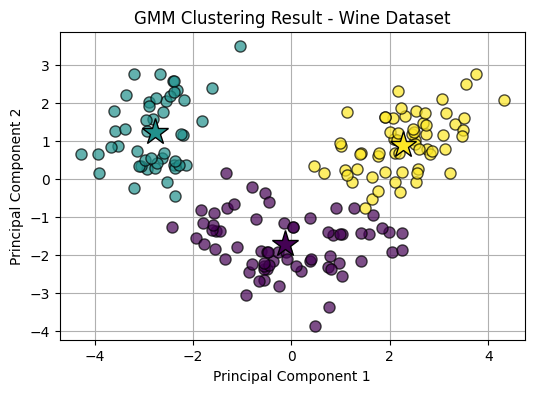

In [20]:
plt.figure(figsize=(6, 4))

# 군집 중심점(평균)
centers = gmm.means_

# 군집별 색상 생성
colors = plt.cm.viridis(np.linspace(0, 1, 3))

for k, col in zip(range(3), colors):
    members = (labels == k)

    # 군집 데이터 포인트
    plt.plot(
        X_pca[members, 0],
        X_pca[members, 1],
        'o',
        markerfacecolor=col,    # 점 내부 색상
        markeredgecolor='k',    # 점 테두리 색상
        markersize=8,
        alpha=0.7,
    )

    # 가우시안 분포 중심점
    plt.plot(
        centers[k, 0],
        centers[k, 1],
        '*',
        markerfacecolor=col,
        markeredgecolor='k',
        markersize=20
    )

plt.title('GMM Clustering Result - Wine Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

## 5. 원본 레이블과의 비교 시각화

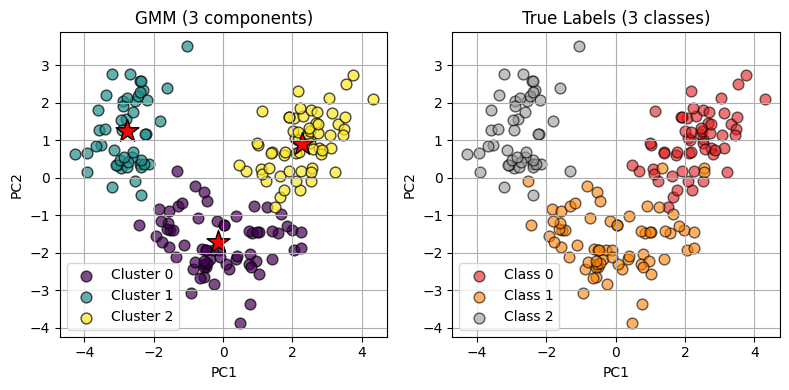

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# GMM 결과
colors_gmm = plt.cm.viridis(np.linspace(0, 1, 3))

for k, col in zip(range(3), colors_gmm):
    members = (labels == k)
    axes[0].scatter(
        X_pca[members, 0],
        X_pca[members, 1],
        c=[col],
        label=f'Cluster {k}',
        s=60,
        edgecolors='k',
        alpha=0.7
    )
    axes[0].scatter(
        centers[k, 0],
        centers[k, 1],
        marker='*',
        c='red',
        s=300,
        edgecolors='k'
    )

axes[0].set_title('GMM (3 components)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()
axes[0].grid(True)

# 원본 레이블
colors_true = plt.cm.Set1(np.linspace(0, 1, len(np.unique(wine.target))))

for k, col in zip(np.unique(wine.target), colors_true):
    my_members = (wine.target == k)
    axes[1].scatter(
        X_pca[my_members, 0],
        X_pca[my_members, 1],
        c=[col],
        label=f'Class {k}',
        s=60,
        edgecolors='k',
        alpha=0.6
    )

axes[1].set_title(f'True Labels ({len(np.unique(wine.target))} classes)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()